# Task 1.1 — Offering Strategy under One-Price Balancing Scheme

We determine the optimal day-ahead (DA) offering strategy for a price-taking wind farm under uncertainty.

---

## Decision Variable

$$
p_t^{DA}
$$

- Power offered in the day-ahead market at hour $t$

---

## Profit per Scenario

For each scenario $\omega$, profit is:

$$
\Pi_{t,\omega} =
p_t^{DA} \cdot \lambda^{DA}_{t,\omega}
+
\left(W_{t,\omega} - p_t^{DA}\right) \cdot \lambda^{B}_{t,\omega}
$$

where:
- $W_{t,\omega}$ = realized wind power  
- $\lambda^{DA}_{t,\omega}$ = day-ahead price  
- $\lambda^{B}_{t,\omega}$ = balancing price  

---

## One-Price Scheme

Under the one-price scheme:

- All imbalances are settled at the balancing price
- No distinction between helpful or harmful deviations

Balancing prices are defined as:

$$
\lambda^{B}_{t,\omega} =
\begin{cases}
1.25 \cdot \lambda^{DA}_{t,\omega}, & \text{if system deficit} \\
0.85 \cdot \lambda^{DA}_{t,\omega}, & \text{if system surplus}
\end{cases}
$$

---

## Objective Function

We maximize expected profit:

$$
\max \mathbb{E}[\Pi] =
\frac{1}{|\Omega|} \sum_{\omega \in \Omega} \sum_{t=1}^{24} \Pi_{t,\omega}
$$

---

## Constraints

$$
0 \leq p_t^{DA} \leq P_{\max}
$$

for all hours $t$.

---

## Notes

- The wind farm is a price-taker
- All scenarios are equally likely
- Total scenarios: $20 \times 20 \times 4 = 1600$

In [30]:
# ============================================
# TASK 1.1 — ONE-PRICE OPTIMIZATION
# ============================================

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

# ----------------------------
# LOAD DATA
# ----------------------------
wind = pd.read_csv("../data/processed/wind_realizations.csv") 
price = pd.read_csv("../data/processed/da_price_scenarios.csv")
imbalance = pd.read_csv("../data/processed/imbalance_scenarios_random.csv")

# Extract arrays (remove Hour column)
W = wind.iloc[:, 1:].values           # (24, 20)
lambda_DA = price.iloc[:, 1:].values  # (24, 20)
SI = imbalance.iloc[:, 1:].values     # (24, 4)

T = 24
N_w = W.shape[1]
N_p = lambda_DA.shape[1]
N_s = SI.shape[1]

print(f"Dimensions: W={W.shape}, lambda_DA={lambda_DA.shape}, SI={SI.shape}")
print(f"Total scenarios: {N_w * N_p * N_s}")


P_max = 500

# ----------------------------
# BUILD FULL SCENARIOS
# ----------------------------
# Expand to 1600 scenarios

W_full = np.repeat(W, N_p * N_s, axis=1)
lambda_DA_full = np.tile(np.repeat(lambda_DA, N_s, axis=1), (1, N_w))
SI_full = np.tile(SI, (1, N_w * N_p))

# Balancing price
lambda_B_full = np.where(
    SI_full == 1,
    1.25 * lambda_DA_full,
    0.85 * lambda_DA_full
)

N_total = W_full.shape[1]

# ----------------------------
# OPTIMIZATION MODEL
# ----------------------------
model = gp.Model("one_price")

# Decision variables
p_DA = model.addVars(T, lb=0, ub=P_max, name="p_DA")

# ----------------------------
# OBJECTIVE FUNCTION
# ----------------------------
profit = 0

for t in range(T):
    for w in range(N_total):
        
        profit += (
            p_DA[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p_DA[t]) * lambda_B_full[t, w]
        )

# Expected value
profit = profit / N_total

model.setObjective(profit, GRB.MAXIMIZE)

# ----------------------------
# SOLVE
# ----------------------------
model.setParam("OutputFlag", 0)
model.optimize()

# ----------------------------
# RESULTS
# ----------------------------
p_opt = np.array([p_DA[t].X for t in range(T)])

results_df = pd.DataFrame({
    "Hour": np.arange(T),
    "Optimal_DA_Offer": p_opt
})

print(results_df)

# ----------------------------
# EXPECTED PROFIT
# ----------------------------
print("Expected Profit:", model.objVal)

Dimensions: W=(24, 20), lambda_DA=(24, 20), SI=(24, 4)
Total scenarios: 1600
    Hour  Optimal_DA_Offer
0      0               0.0
1      1             500.0
2      2               0.0
3      3             500.0
4      4             500.0
5      5             500.0
6      6               0.0
7      7               0.0
8      8               0.0
9      9             500.0
10    10             500.0
11    11               0.0
12    12               0.0
13    13               0.0
14    14             500.0
15    15             500.0
16    16               0.0
17    17               0.0
18    18               0.0
19    19             500.0
20    20               0.0
21    21               0.0
22    22               0.0
23    23               0.0
Expected Profit: 464595.2229986868


## Interpretation of Results — One-Price Scheme

The optimal day-ahead offering strategy exhibits a **bang-bang behavior**, where the wind producer either bids zero or full capacity in each hour.

---

### Analytical Explanation

The profit for a given scenario can be written as:

$$
\Pi_{t,\omega} = p_t^{DA} \lambda^{DA}_{t,\omega} + \left(W_{t,\omega} - p_t^{DA}\right)\lambda^{B}_{t,\omega}
$$

Rearranging:

$$
\Pi_{t,\omega} = W_{t,\omega} \lambda^{B}_{t,\omega} + p_t^{DA} \left(\lambda^{DA}_{t,\omega} - \lambda^{B}_{t,\omega}\right)
$$

Since the first term is independent of the decision variable, the optimization depends only on:

$$
p_t^{DA} \left(\lambda^{DA}_{t,\omega} - \lambda^{B}_{t,\omega}\right)
$$

---

### Economic Interpretation

The optimal decision depends on the **expected price spread**:

$$
\mathbb{E}[\lambda^{DA} - \lambda^{B}]
$$

- If the expected spread is **positive**, it is optimal to bid maximum capacity:
  $$
  p_t^{DA} = P_{\max}
  $$

- If the expected spread is **negative**, it is optimal to bid zero:
  $$
  p_t^{DA} = 0
  $$

This leads to corner solutions, as there is no incentive to choose intermediate values.

---

### Role of the One-Price Scheme

Under the one-price balancing mechanism:

- All imbalances are settled at the balancing price,
- No distinction is made between helpful and harmful deviations.

As a result, the wind producer is not penalized asymmetrically for forecast errors, and the decision depends purely on the expected relationship between day-ahead and balancing prices.

---

### Conclusion

The observed all-or-nothing bidding strategy is a direct consequence of the linear structure of the objective function and the symmetric treatment of imbalances in the one-price scheme. This behavior highlights the lack of risk exposure associated with imbalance direction, leading to extreme bidding strategies.

Mean: 464595.22
Std: 340871.49
5th percentile: 65707.60
Median: 382317.78
95th percentile: 1128237.18


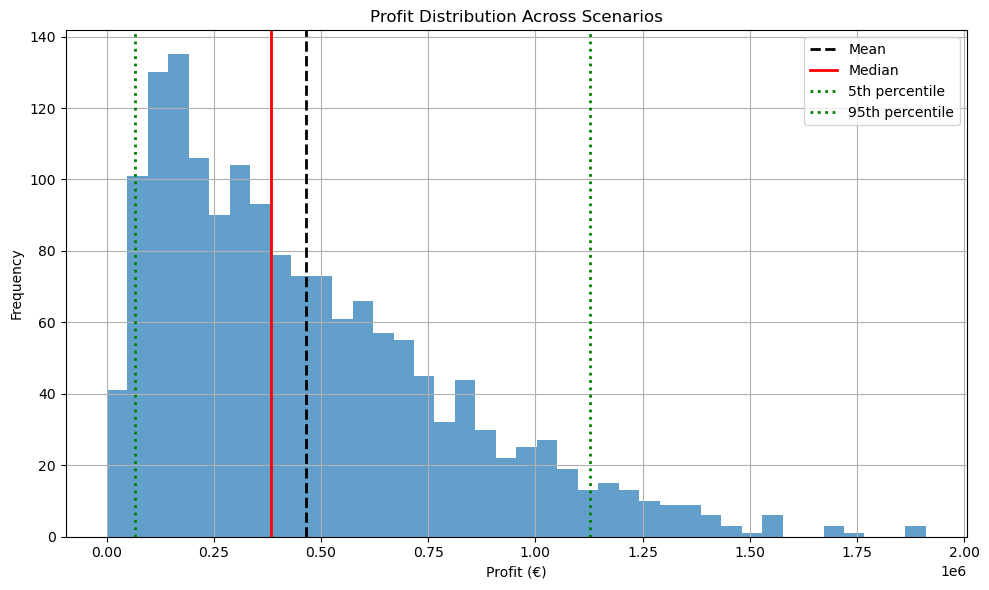

In [31]:
# ============================================
# IMPROVED PROFIT DISTRIBUTION PLOT
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# COMPUTE PROFIT PER SCENARIO
# ----------------------------
profits = np.zeros(N_total)

for w in range(N_total):
    for t in range(T):
        profits[w] += (
            p_opt[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p_opt[t]) * lambda_B_full[t, w]
        )

# ----------------------------
# STATISTICS
# ----------------------------
mean_profit = profits.mean()
std_profit = profits.std()
p5, p50, p95 = np.percentile(profits, [5, 50, 95])

print(f"Mean: {mean_profit:.2f}")
print(f"Std: {std_profit:.2f}")
print(f"5th percentile: {p5:.2f}")
print(f"Median: {p50:.2f}")
print(f"95th percentile: {p95:.2f}")

plt.figure(figsize=(10,6))

# Histogram
plt.hist(profits, bins=40, alpha=0.7)

# Lines with clear colors
plt.axvline(mean_profit, linestyle='--', linewidth=2, color='black', label="Mean")
plt.axvline(p50, linestyle='-', linewidth=2, color='red', label="Median")
plt.axvline(p5, linestyle=':', linewidth=2, color='green', label="5th percentile")
plt.axvline(p95, linestyle=':', linewidth=2, color='green', label="95th percentile")

# Labels
plt.xlabel("Profit (€)")
plt.ylabel("Frequency")
plt.title("Profit Distribution Across Scenarios")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Task 1.4 — Risk-Averse Offering Strategy

In this section, the stochastic offering strategy is extended to account for risk aversion by including a Conditional Value-at-Risk (CVaR) term in the objective function.

The producer no longer maximizes only the expected profit, but instead balances expected profit against downside risk. This allows us to study how the optimal day-ahead offering strategy changes as the degree of risk aversion increases.

The analysis is carried out for several values of the risk-aversion parameter, ranging from risk-neutral to highly risk-averse behavior.



## Risk-Averse Model Formulation

The objective is defined as

$$
\max \; (1-\beta)\,\mathbb{E}[\Pi_\omega] + \beta\,\mathrm{CVaR}_\beta(\Pi_\omega)
$$

where:
- $\Pi_\omega$ is the profit in scenario $\omega$,
- $\beta \in [0,1]$ is the risk-aversion parameter,
- $\beta$ is the confidence level.

The CVaR term is linearized as

$$
\mathrm{CVaR}_\alpha(\Pi_\omega)
=
\zeta - \frac{1}{1-\alpha}\sum_{\omega \in \Omega}\pi_\omega \eta_\omega
$$

subject to

$$
\eta_\omega \geq \zeta - \Pi_\omega, \qquad \eta_\omega \geq 0
\qquad \forall \omega \in \Omega
$$

When $\beta = 0$, the model is risk-neutral and coincides with the stochastic offering strategy of Task 1.1. As $\lambda$ increases, the producer places more emphasis on avoiding low-profit outcomes.

In [34]:
# ============================================
# TASK 1.4 — EFFICIENT FRONTIER (ONE-PRICE)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

alpha = 0.90                     # CVaR confidence level
beta_values = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

frontier_results = []
offer_profiles = []

for beta in beta_values:

    model_ra = gp.Model(f"one_price_beta_{beta:.2f}")
    model_ra.setParam("OutputFlag", 0)

    # ----------------------------
    # Decision variables
    # ----------------------------
    p_DA_ra = model_ra.addVars(T, lb=0, ub=P_max, name="p_DA")

    # CVaR variables
    zeta = model_ra.addVar(lb=-GRB.INFINITY, name="zeta")
    eta = model_ra.addVars(N_total, lb=0, name="eta")

    # ----------------------------
    # Scenario profit expressions
    # ----------------------------
    profit_s = {}

    for w in range(N_total):
        expr = 0
        for t in range(T):
            expr += (
                p_DA_ra[t] * lambda_DA_full[t, w]
                + (W_full[t, w] - p_DA_ra[t]) * lambda_B_full[t, w]
            )
        profit_s[w] = expr

    # Expected profit
    expected_profit = gp.quicksum(profit_s[w] for w in range(N_total)) / N_total

    # CVaR constraints
    for w in range(N_total):
        model_ra.addConstr(eta[w] >= zeta - profit_s[w], name=f"shortfall_{w}")

    cvar = zeta - (1 / (1 - alpha)) * gp.quicksum(eta[w] for w in range(N_total)) / N_total

    # Objective
    model_ra.setObjective(
        (1 - beta) * expected_profit + beta * cvar,
        GRB.MAXIMIZE
    )

    # Solve
    model_ra.optimize()

    # Optimal DA offer
    p_opt_ra = np.array([p_DA_ra[t].X for t in range(T)])
    offer_profiles.append(p_opt_ra)

    # Evaluate realized scenario profits
    profits_ra = np.zeros(N_total)

    for w in range(N_total):
        for t in range(T):
            profits_ra[w] += (
                p_opt_ra[t] * lambda_DA_full[t, w]
                + (W_full[t, w] - p_opt_ra[t]) * lambda_B_full[t, w]
            )

    mean_profit = profits_ra.mean()
    zeta_val = zeta.X
    cvar_eval = zeta_val - (1 / (1 - alpha)) * np.mean(np.maximum(zeta_val - profits_ra, 0))
    std_profit = profits_ra.std()

    frontier_results.append({
        "beta": beta,
        "expected_profit": mean_profit,
        "CVaR": cvar_eval,
        "std_profit": std_profit
    })

# Results table
frontier_df = pd.DataFrame(frontier_results)
print(frontier_df)

    beta  expected_profit          CVaR     std_profit
0    0.0    464595.222999    646.696490  340871.492829
1    0.1    464595.222999  64156.717468  340871.492829
2    0.2    464595.222999  64156.717468  340871.492829
3    0.3    464595.222999  64156.717468  340871.492829
4    0.4    464595.222999  64156.717468  340871.492829
5    0.5    464595.222999  64156.717468  340871.492829
6    0.6    464595.222999  64156.717468  340871.492829
7    0.7    464595.222999  64156.717468  340871.492829
8    0.8    464595.222999  64156.717468  340871.492829
9    0.9    464595.222999  64156.717468  340871.492829
10   1.0    463985.965580  64193.262521  340609.551801


## Efficient frontier

To analyze the trade-off between expected profit and downside risk, the risk-aversion parameter $\beta$ is varied between 0 and 1.

For each value of $\beta$, the model is solved and the corresponding expected profit and CVaR are computed. Plotting expected profit against CVaR yields the efficient frontier.

The point $\beta=0$ corresponds to the risk-neutral solution, while larger values of $\beta$ represent increasingly risk-averse strategies.


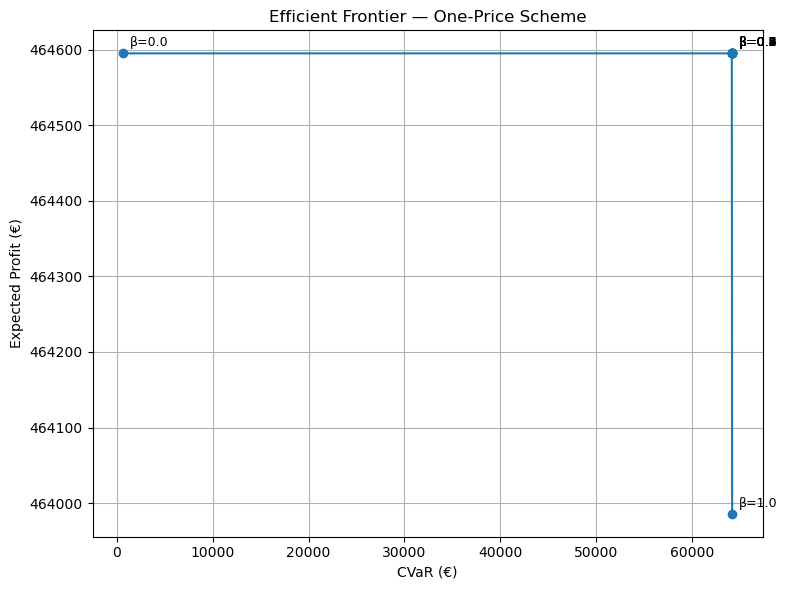

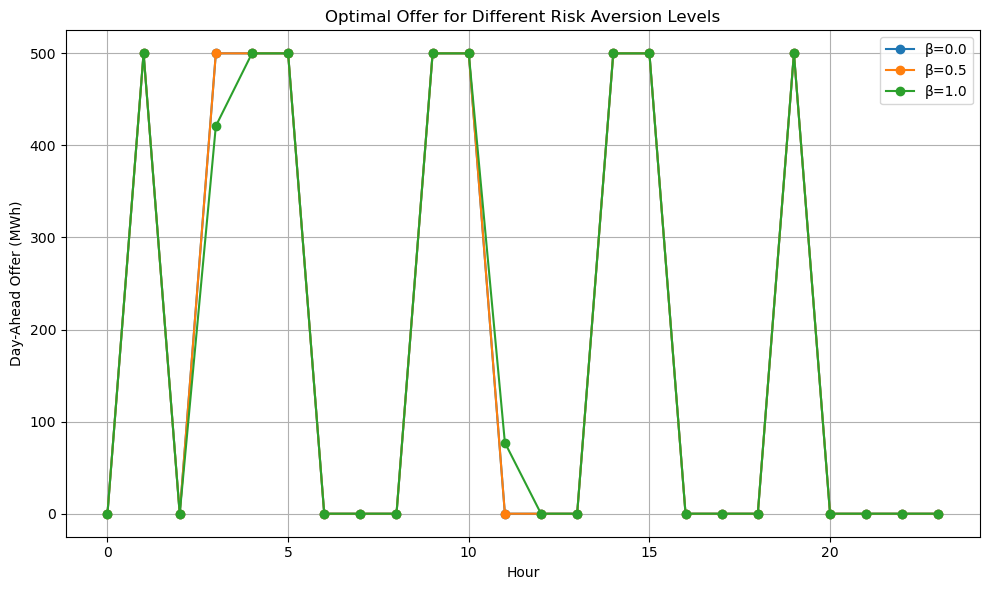

In [35]:
# ============================================
# EFFICIENT FRONTIER PLOT
# ============================================

plt.figure(figsize=(8,6))

plt.plot(frontier_df["CVaR"], frontier_df["expected_profit"], marker='o')

for i, row in frontier_df.iterrows():
    plt.annotate(f"β={row['beta']:.1f}",
                 (row["CVaR"], row["expected_profit"]),
                 textcoords="offset points",
                 xytext=(5,5),
                 fontsize=9)

plt.xlabel("CVaR (€)")
plt.ylabel("Expected Profit (€)")
plt.title("Efficient Frontier — One-Price Scheme")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# OFFER PROFILES FOR DIFFERENT BETA VALUES
# ============================================

plt.figure(figsize=(10,6))

selected_idx = [0, 5, 10]   # beta = 0.0, 0.5, 1.0

for idx in selected_idx:
    plt.plot(np.arange(T), offer_profiles[idx], marker='o', label=f"β={beta_values[idx]:.1f}")

plt.xlabel("Hour")
plt.ylabel("Day-Ahead Offer (MWh)")
plt.title("Optimal Offer for Different Risk Aversion Levels")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()